# 🌳 Arbres de Décision — Notebook d'application

**Master 2 Data Science — Big Data & IA**

---

## Objectifs pédagogiques

À la fin de ce notebook, vous serez capable de :

1. **Charger et explorer** un dataset réel de scoring crédit
2. **Analyser et visualiser** les données (EDA)
3. **Prétraiter** les données pour la modélisation
4. **Construire et évaluer** un arbre de décision avec scikit-learn
5. **Optimiser** les hyperparamètres et lutter contre l'overfitting
6. **Interpréter** les résultats et l'importance des variables

---

## Contexte métier

> Vous êtes Data Scientist dans une banque d'Afrique de l'Ouest. Le département **Risque Crédit**
> vous demande de construire un modèle pour prédire si un client va faire **défaut sur son crédit**.
> L'objectif est d'automatiser et d'objectiver les décisions d'octroi de crédit.

**Variable cible** : `DEFAUT` — 1 = le client a fait défaut, 0 = remboursement normal

---
## ⚙️ 0. Imports & configuration
---

In [2]:
# ── Librairies standard ──────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ─────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score
)
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# ── Style global ─────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize':  (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('husl')

print('✅ Imports OK — Python', __import__('sys').version.split()[0])

✅ Imports OK — Python 3.8.10


---
## 📂 1. Chargement des données
---

### Dataset : Scoring Crédit Bancaire

Le dataset contient **2 000 demandes de crédit** avec les caractéristiques suivantes :

| Variable | Type | Description |
|----------|------|-------------|
| `AGE` | Numérique | Âge du client (années) |
| `SALAIRE_MENSUEL` | Numérique | Salaire net mensuel (XOF) |
| `DUREE_EMPLOI` | Numérique | Ancienneté dans l'emploi actuel (mois) |
| `MONTANT_CREDIT` | Numérique | Montant du crédit demandé (XOF) |
| `DUREE_CREDIT` | Numérique | Durée de remboursement (mois) |
| `NB_CREDITS_EN_COURS` | Numérique | Nombre de crédits actifs |
| `RATIO_ENDETTEMENT` | Numérique | Charges / Revenus (%) |
| `HISTORIQUE` | Catégorielle | Qualité historique crédit : Excellent / Bon / Moyen / Mauvais |
| `TYPE_EMPLOI` | Catégorielle | Salarié / Indépendant / Fonctionnaire / Sans emploi |
| `GARANTIE` | Catégorielle | Type de garantie : Immobilière / Véhicule / Caution / Aucune |
| `NB_INCIDENTS` | Numérique | Incidents de paiement passés |
| `DEFAUT` | **Cible** | 1 = défaut, 0 = remboursement normal |

In [3]:
# ── Génération du dataset (reproductible) ────────────────
np.random.seed(42)
N = 2000

# Variables numériques
age              = np.random.randint(22, 65, N)
salaire          = np.random.randint(150_000, 2_500_000, N)
duree_emploi     = np.random.randint(0, 360, N)  # mois
montant_credit   = np.random.randint(500_000, 50_000_000, N)
duree_credit     = np.random.choice([12, 24, 36, 48, 60, 84, 120], N)
nb_credits       = np.random.randint(0, 6, N)
nb_incidents     = np.random.randint(0, 8, N)
ratio_endettement = np.round(np.random.beta(2, 5, N) * 80 + 5, 1)

# Variables catégorielles
historique = np.random.choice(
    ['Excellent', 'Bon', 'Moyen', 'Mauvais'],
    N, p=[0.25, 0.35, 0.25, 0.15]
)
type_emploi = np.random.choice(
    ['Salarié', 'Fonctionnaire', 'Indépendant', 'Sans emploi'],
    N, p=[0.45, 0.25, 0.22, 0.08]
)
garantie = np.random.choice(
    ['Immobilière', 'Véhicule', 'Caution', 'Aucune'],
    N, p=[0.30, 0.25, 0.30, 0.15]
)

# Variable cible — construite avec une logique métier réaliste
score = (
    -0.3 * (ratio_endettement / 80)
    -0.25 * (nb_incidents / 7)
    -0.15 * (nb_credits / 5)
    +0.2  * (salaire / 2_500_000)
    +0.1  * (duree_emploi / 360)
    +np.where(historique == 'Excellent',  0.20, 0)
    +np.where(historique == 'Bon',         0.08, 0)
    +np.where(historique == 'Mauvais',    -0.25, 0)
    +np.where(type_emploi == 'Fonctionnaire', 0.10, 0)
    +np.where(type_emploi == 'Sans emploi',  -0.20, 0)
    +np.where(garantie == 'Aucune',          -0.12, 0)
    +np.random.normal(0, 0.08, N)  # bruit
)
prob_defaut = 1 / (1 + np.exp(3 * score))  # sigmoid
defaut = (np.random.uniform(0, 1, N) < prob_defaut).astype(int)

# Injection de valeurs manquantes (~3%)
idx_nan_sal  = np.random.choice(N, size=45, replace=False)
idx_nan_hist = np.random.choice(N, size=38, replace=False)
idx_nan_dur  = np.random.choice(N, size=30, replace=False)

salaire_nan     = salaire.astype(float)
historique_nan  = np.array(historique, dtype=object)
duree_nan       = duree_emploi.astype(float)
salaire_nan[idx_nan_sal]    = np.nan
historique_nan[idx_nan_hist] = np.nan
duree_nan[idx_nan_dur]      = np.nan

# ── Construction du DataFrame ─────────────────────────────
df = pd.DataFrame({
    'AGE':                age,
    'SALAIRE_MENSUEL':     salaire_nan,
    'DUREE_EMPLOI':        duree_nan,
    'MONTANT_CREDIT':      montant_credit,
    'DUREE_CREDIT':        duree_credit,
    'NB_CREDITS_EN_COURS': nb_credits,
    'RATIO_ENDETTEMENT':   ratio_endettement,
    'HISTORIQUE':          historique_nan,
    'TYPE_EMPLOI':         type_emploi,
    'GARANTIE':            garantie,
    'NB_INCIDENTS':        nb_incidents,
    'DEFAUT':              defaut,
})

print(f'✅ Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')
df.head(10)

✅ Dataset chargé : 2000 lignes × 12 colonnes


,AGE,SALAIRE_MENSUEL,DUREE_EMPLOI,MONTANT_CREDIT,DUREE_CREDIT,NB_CREDITS_EN_COURS,RATIO_ENDETTEMENT,HISTORIQUE,TYPE_EMPLOI,GARANTIE,NB_INCIDENTS,DEFAUT
0,60,2236213.0,184.0,5593388,120,1,24.9,NaN,Salarié,Immobilière,4,0
1,50,1651681.0,359.0,13553367,24,0,12.4,Excellent,Indépendant,Caution,1,0
2,36,NaN,291.0,24237361,120,1,18.7,Mauvais,Fonctionnaire,Véhicule,3,0
3,64,698884.0,334.0,20756880,36,5,26.1,Moyen,Salarié,Caution,4,0
4,29,2149254.0,219.0,29204996,120,3,29.5,Bon,Sans emploi,Caution,0,0
5,42,1000538.0,115.0,16441926,60,1,42.9,Moyen,Salarié,Immobilière,3,0
6,60,1137471.0,312.0,11547100,24,2,43.4,Bon,Indépendant,Caution,3,1
7,40,209182.0,48.0,38699721,12,4,26.7,Mauvais,Salarié,Caution,1,1
8,44,1516808.0,172.0,11031792,84,5,32.0,Excellent,Fonctionnaire,Véhicule,1,1
9,32,1851667.0,81.0,9393518,48,5,19.6,Moyen,Salarié,Immobilière,2,0


---
## 🔍 2. Analyse Exploratoire (EDA)
---

### 2.1 Aperçu général du dataset

In [4]:
# Dimensions, types et mémoire
print('=' * 55)
print(f'  Dimensions     : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'  Mémoire        : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print('=' * 55)
df.info()

  Dimensions     : 2,000 lignes × 12 colonnes
  Mémoire        : 530.0 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AGE                  2000 non-null   int32  
 1   SALAIRE_MENSUEL      1955 non-null   float64
 2   DUREE_EMPLOI         1970 non-null   float64
 3   MONTANT_CREDIT       2000 non-null   int32  
 4   DUREE_CREDIT         2000 non-null   int32  
 5   NB_CREDITS_EN_COURS  2000 non-null   int32  
 6   RATIO_ENDETTEMENT    2000 non-null   float64
 7   HISTORIQUE           1962 non-null   object 
 8   TYPE_EMPLOI          2000 non-null   object 
 9   GARANTIE             2000 non-null   object 
 10  NB_INCIDENTS         2000 non-null   int32  
 11  DEFAUT               2000 non-null   int32  
dtypes: float64(3), int32(6), object(3)
memory usage: 140.8+ KB


### 2.2 Statistiques descriptives

In [5]:
# Variables numériques
df.describe().round(2)

,AGE,SALAIRE_MENSUEL,DUREE_EMPLOI,MONTANT_CREDIT,DUREE_CREDIT,NB_CREDITS_EN_COURS,RATIO_ENDETTEMENT,NB_INCIDENTS,DEFAUT
count,2000.00,1955.00,1970.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,43.11,1351478.33,181.56,24855414.87,54.87,2.46,27.63,3.58,0.56
std,12.31,674253.93,103.51,14223968.44,35.06,1.70,12.83,2.28,0.50
min,22.00,150159.00,0.00,506464.00,12.00,0.00,5.50,0.00,0.00
25%,32.00,782332.00,94.00,12494564.25,24.00,1.00,17.80,2.00,0.00
50%,44.00,1358948.00,185.00,25075946.50,48.00,2.00,25.80,4.00,1.00
75%,54.00,1919726.00,271.00,37319527.00,84.00,4.00,35.50,6.00,1.00
max,64.00,2499316.00,359.00,49989426.00,120.00,5.00,71.50,7.00,1.00


In [6]:
# Variables catégorielles
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f'\n── {col} ──────────────')
    print(df[col].value_counts(dropna=False))


── HISTORIQUE ──────────────
HISTORIQUE
Bon          681
Excellent    492
Moyen        488
Mauvais      301
NaN           38
Name: count, dtype: int64

── TYPE_EMPLOI ──────────────
TYPE_EMPLOI
Salarié          910
Fonctionnaire    473
Indépendant      454
Sans emploi      163
Name: count, dtype: int64

── GARANTIE ──────────────
GARANTIE
Caution        598
Immobilière    592
Véhicule       488
Aucune         322
Name: count, dtype: int64


### 2.3 Valeurs manquantes

Variables avec des valeurs manquantes :
                 Nb manquants  % manquants
SALAIRE_MENSUEL            45         2.25
HISTORIQUE                 38         1.90
DUREE_EMPLOI               30         1.50


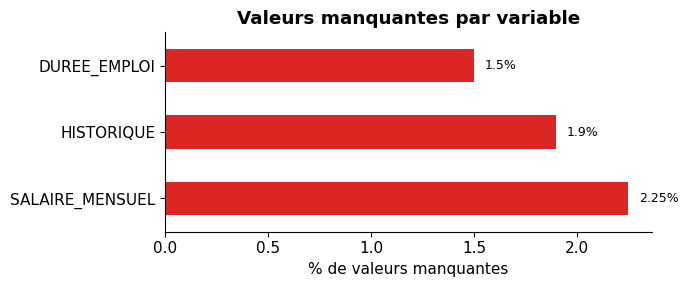

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Nb manquants': missing, '% manquants': missing_pct})
miss_df = miss_df[miss_df['Nb manquants'] > 0].sort_values('% manquants', ascending=False)

print('Variables avec des valeurs manquantes :')
print(miss_df)

# Visualisation
fig, ax = plt.subplots(figsize=(7, 3))
miss_df['% manquants'].plot(kind='barh', ax=ax, color='#DC2626')
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Valeurs manquantes par variable', fontweight='bold')
for i, (val, _) in enumerate(miss_df.iterrows()):
    ax.text(miss_df.loc[val, '% manquants'] + 0.05, i,
            f"{miss_df.loc[val, '% manquants']}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 2.4 Distribution de la variable cible

Distribution de la variable cible DEFAUT :
        Nombre  Pourcentage
DEFAUT                     
1         1126         56.3
0          874         43.7


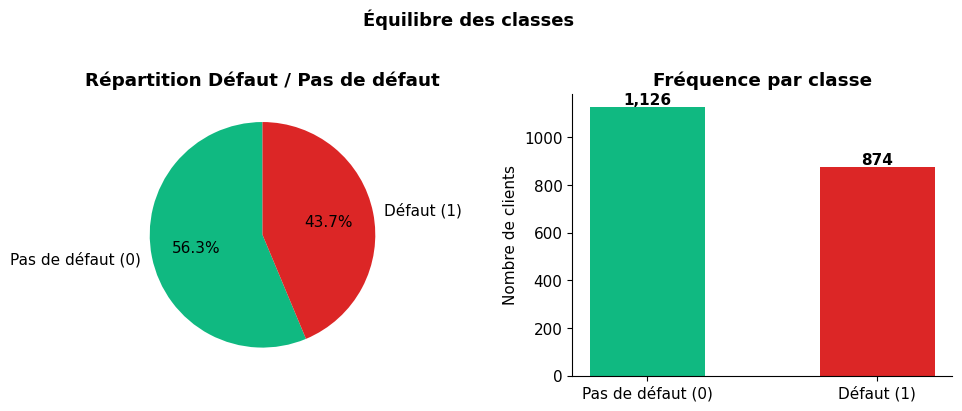

In [8]:
count_def = df['DEFAUT'].value_counts()
pct_def   = df['DEFAUT'].value_counts(normalize=True) * 100

print('Distribution de la variable cible DEFAUT :')
print(pd.DataFrame({'Nombre': count_def, 'Pourcentage': pct_def.round(1)}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Camembert
axes[0].pie(count_def, labels=['Pas de défaut (0)', 'Défaut (1)'],
            colors=['#10B981', '#DC2626'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Répartition Défaut / Pas de défaut', fontweight='bold')

# Barres
bars = axes[1].bar(['Pas de défaut (0)', 'Défaut (1)'], count_def.values,
                   color=['#10B981', '#DC2626'], width=0.5)
axes[1].set_ylabel('Nombre de clients')
axes[1].set_title('Fréquence par classe', fontweight='bold')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{int(bar.get_height()):,}', ha='center', fontweight='bold')

plt.suptitle('Équilibre des classes', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **💡 À noter** : Le dataset est-il équilibré ? Un déséquilibre important nécessiterait des techniques
> spécifiques (oversampling, undersampling, class_weight...).

### 2.5 Distribution des variables numériques selon le défaut

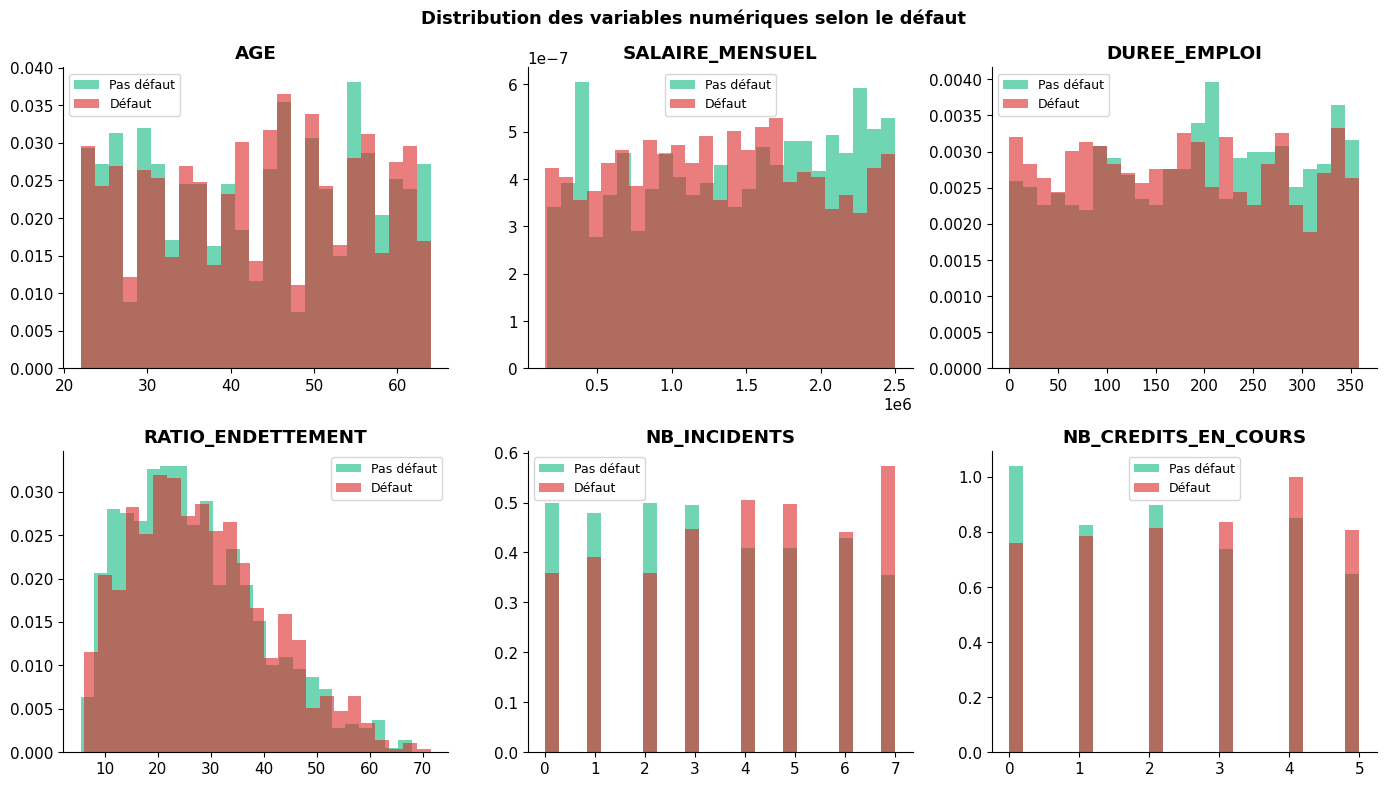

In [9]:
num_cols = ['AGE', 'SALAIRE_MENSUEL', 'DUREE_EMPLOI',
            'RATIO_ENDETTEMENT', 'NB_INCIDENTS', 'NB_CREDITS_EN_COURS']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for val, color, label in [(0, '#10B981', 'Pas défaut'), (1, '#DC2626', 'Défaut')]:
        data = df[df['DEFAUT'] == val][col].dropna()
        axes[i].hist(data, bins=25, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].set_xlabel('')

plt.suptitle('Distribution des variables numériques selon le défaut',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.6 Taux de défaut par variable catégorielle

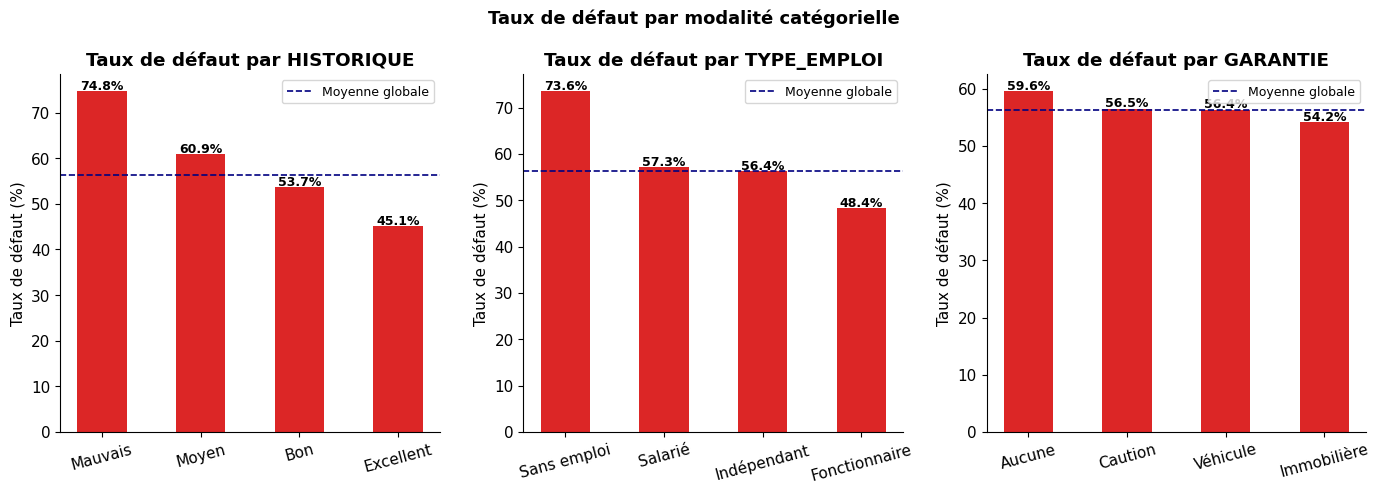

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
cat_vars = ['HISTORIQUE', 'TYPE_EMPLOI', 'GARANTIE']

for i, col in enumerate(cat_vars):
    taux = df.groupby(col)['DEFAUT'].mean().sort_values(ascending=False) * 100
    colors = ['#DC2626' if v > 30 else '#F59E0B' if v > 15 else '#10B981'
              for v in taux.values]
    bars = axes[i].bar(taux.index, taux.values, color=colors, width=0.5)
    axes[i].set_title(f'Taux de défaut par {col}', fontweight='bold')
    axes[i].set_ylabel('Taux de défaut (%)')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].axhline(df['DEFAUT'].mean()*100, color='navy',
                    linestyle='--', linewidth=1.2, label='Moyenne globale')
    axes[i].legend(fontsize=9)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f"{bar.get_height():.1f}%", ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Taux de défaut par modalité catégorielle',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.7 Matrice de corrélation

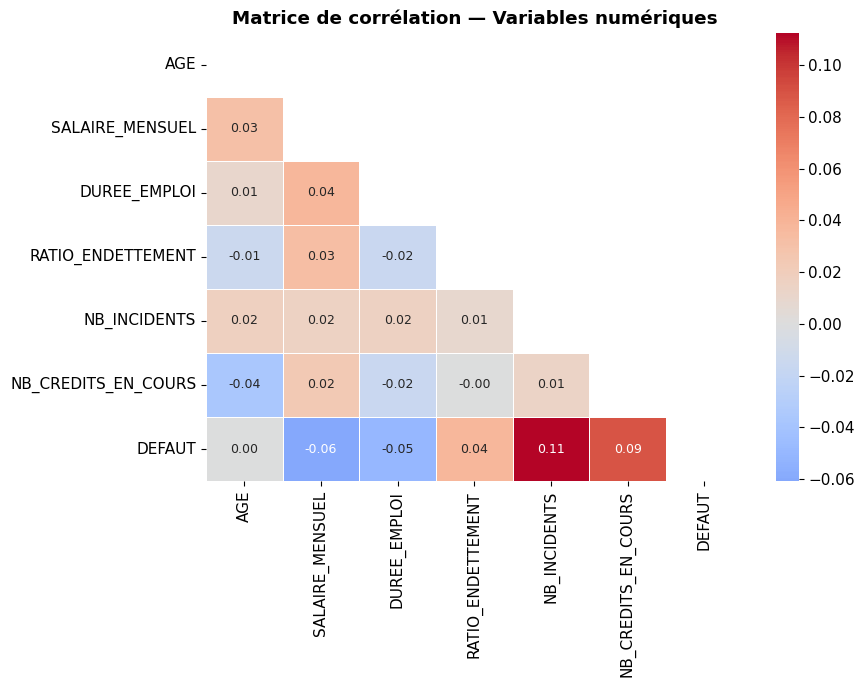


Corrélations avec DEFAUT (triées) :
NB_INCIDENTS           0.112
NB_CREDITS_EN_COURS    0.089
SALAIRE_MENSUEL       -0.061
DUREE_EMPLOI          -0.050
RATIO_ENDETTEMENT      0.038
AGE                    0.000
Name: DEFAUT, dtype: float64


In [11]:
num_df = df[num_cols + ['DEFAUT']].dropna()
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Matrice de corrélation — Variables numériques', fontweight='bold')
plt.tight_layout()
plt.show()

# Variables les plus corrélées avec DEFAUT
print('\nCorrélations avec DEFAUT (triées) :')
print(corr['DEFAUT'].drop('DEFAUT').sort_values(key=abs, ascending=False).round(3))

> **✏️ Exercice 1** — Calculez le taux de défaut moyen selon la `DUREE_CREDIT`. Affichez un graphique en barres. Interprétez le résultat.

In [ ]:
# Exercice 1 — Taux de défaut selon la durée du crédit
# Hint : utilisez groupby + mean + bar chart

# Votre code ici


> **✏️ Exercice 2** — Créez une nouvelle variable `MENSUALITE_ESTIMEE = MONTANT_CREDIT / DUREE_CREDIT`. Comparez sa distribution entre les clients en défaut et les clients sains.

In [ ]:
# Exercice 2 — Création et analyse d'une nouvelle variable

# Votre code ici


---
## 🔧 3. Prétraitement des données
---

### 3.1 Traitement des valeurs manquantes

In [12]:
df_clean = df.copy()

# ── Variables numériques : imputation par la médiane ─────
for col in ['SALAIRE_MENSUEL', 'DUREE_EMPLOI']:
    mediane = df_clean[col].median()
    nb_remplaces = df_clean[col].isna().sum()
    df_clean[col] = df_clean[col].fillna(mediane)
    print(f'  {col} : {nb_remplaces} valeurs → médiane = {mediane:,.0f}')

# ── Variable catégorielle : imputation par le mode ────────
mode_hist = df_clean['HISTORIQUE'].mode()[0]
nb_hist   = df_clean['HISTORIQUE'].isna().sum()
df_clean['HISTORIQUE'] = df_clean['HISTORIQUE'].fillna(mode_hist)
print(f'  HISTORIQUE : {nb_hist} valeurs → mode = {mode_hist}')

# Vérification
assert df_clean.isnull().sum().sum() == 0, 'Il reste des NaN !'
print(f'\n✅ Aucune valeur manquante restante.')

  SALAIRE_MENSUEL : 45 valeurs → médiane = 1,358,948
  DUREE_EMPLOI : 30 valeurs → médiane = 185
  HISTORIQUE : 38 valeurs → mode = Bon

✅ Aucune valeur manquante restante.


### 3.2 Ingénierie de variables (Feature Engineering)

In [13]:
# Nouvelles variables métier utiles
df_clean['MENSUALITE_ESTIMEE'] = (df_clean['MONTANT_CREDIT'] /
                                   df_clean['DUREE_CREDIT'])

df_clean['RATIO_CREDIT_SALAIRE'] = (df_clean['MONTANT_CREDIT'] /
                                     df_clean['SALAIRE_MENSUEL']).round(2)

df_clean['A_INCIDENTS'] = (df_clean['NB_INCIDENTS'] > 0).astype(int)

df_clean['ANCIENNETE_ANNEES'] = (df_clean['DUREE_EMPLOI'] / 12).round(1)

print('Nouvelles variables créées :')
print(df_clean[['MENSUALITE_ESTIMEE', 'RATIO_CREDIT_SALAIRE',
                 'A_INCIDENTS', 'ANCIENNETE_ANNEES']].describe().round(2))

Nouvelles variables créées :
       MENSUALITE_ESTIMEE  RATIO_CREDIT_SALAIRE  A_INCIDENTS  \
count             2000.00               2000.00      2000.00   
mean            763907.36                 27.98         0.88   
std             831847.66                 32.89         0.32   
min               4415.11                  0.24         0.00   
25%             228705.01                  9.33         1.00   
50%             475036.88                 18.31         1.00   
75%             954402.94                 31.57         1.00   
max            4164604.33                244.35         1.00   

       ANCIENNETE_ANNEES  
count            2000.00  
mean               15.13  
std                 8.56  
min                 0.00  
25%                 7.88  
50%                15.40  
75%                22.50  
max                29.90  


### 3.3 Encodage des variables catégorielles

In [14]:
df_model = df_clean.copy()

# ── Ordinal Encoding : HISTORIQUE (avec ordre logique) ────
enc_hist = OrdinalEncoder(
    categories=[['Mauvais', 'Moyen', 'Bon', 'Excellent']]
)
df_model['HISTORIQUE_ENC'] = enc_hist.fit_transform(
    df_model[['HISTORIQUE']]
)
print('HISTORIQUE — Mapping :')
for cat, val in zip(['Mauvais','Moyen','Bon','Excellent'], [0,1,2,3]):
    print(f'  {cat:12} → {val}')

# ── One-Hot Encoding : TYPE_EMPLOI et GARANTIE ────────────
df_model = pd.get_dummies(
    df_model,
    columns=['TYPE_EMPLOI', 'GARANTIE'],
    drop_first=True,  # évite la multicolinéarité
    dtype=int
)

# Suppression des colonnes originales
df_model.drop(columns=['HISTORIQUE'], inplace=True)

print(f'\n✅ Dataset encodé : {df_model.shape[1]} colonnes')
print('Colonnes finales :')
print(df_model.columns.tolist())

HISTORIQUE — Mapping :
  Mauvais      → 0
  Moyen        → 1
  Bon          → 2
  Excellent    → 3

✅ Dataset encodé : 20 colonnes
Colonnes finales :
['AGE', 'SALAIRE_MENSUEL', 'DUREE_EMPLOI', 'MONTANT_CREDIT', 'DUREE_CREDIT', 'NB_CREDITS_EN_COURS', 'RATIO_ENDETTEMENT', 'NB_INCIDENTS', 'DEFAUT', 'MENSUALITE_ESTIMEE', 'RATIO_CREDIT_SALAIRE', 'A_INCIDENTS', 'ANCIENNETE_ANNEES', 'HISTORIQUE_ENC', 'TYPE_EMPLOI_Indépendant', 'TYPE_EMPLOI_Salarié', 'TYPE_EMPLOI_Sans emploi', 'GARANTIE_Caution', 'GARANTIE_Immobilière', 'GARANTIE_Véhicule']


In [28]:
df_model.head()

,AGE,SALAIRE_MENSUEL,DUREE_EMPLOI,MONTANT_CREDIT,DUREE_CREDIT,NB_CREDITS_EN_COURS,RATIO_ENDETTEMENT,NB_INCIDENTS,DEFAUT,MENSUALITE_ESTIMEE,RATIO_CREDIT_SALAIRE,A_INCIDENTS,ANCIENNETE_ANNEES,HISTORIQUE_ENC,TYPE_EMPLOI_Indépendant,TYPE_EMPLOI_Salarié,TYPE_EMPLOI_Sans emploi,GARANTIE_Caution,GARANTIE_Immobilière,GARANTIE_Véhicule
0,60,2236213.0,184.0,5593388,120,1,24.9,4,0,46611.566667,2.50,1,15.3,2.0,0,1,0,0,1,0
1,50,1651681.0,359.0,13553367,24,0,12.4,1,0,564723.625000,8.21,1,29.9,3.0,1,0,0,1,0,0
2,36,1358948.0,291.0,24237361,120,1,18.7,3,0,201978.008333,17.84,1,24.2,0.0,0,0,0,0,0,1
3,64,698884.0,334.0,20756880,36,5,26.1,4,0,576580.000000,29.70,1,27.8,1.0,0,1,0,1,0,0
4,29,2149254.0,219.0,29204996,120,3,29.5,0,0,243374.966667,13.59,0,18.2,2.0,0,0,1,1,0,0


### 3.4 Séparation features / cible et split train/test

In [15]:
# ── Features et cible ────────────────────────────────────
TARGET = 'DEFAUT'
FEATURES = [c for c in df_model.columns if c != TARGET]

X = df_model[FEATURES]
y = df_model[TARGET]

print(f'Features ({len(FEATURES)}) : {FEATURES}')
print(f'\nCible    : {TARGET}')

# ── Split 80/20 stratifié ─────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'\n✅ Split réalisé :')
print(f'  Train : {X_train.shape[0]:,} observations ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Test  : {X_test.shape[0]:,} observations ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\n  Taux de défaut — Train : {y_train.mean()*100:.1f}%')
print(f'  Taux de défaut — Test  : {y_test.mean()*100:.1f}%')

Features (19) : ['AGE', 'SALAIRE_MENSUEL', 'DUREE_EMPLOI', 'MONTANT_CREDIT', 'DUREE_CREDIT', 'NB_CREDITS_EN_COURS', 'RATIO_ENDETTEMENT', 'NB_INCIDENTS', 'MENSUALITE_ESTIMEE', 'RATIO_CREDIT_SALAIRE', 'A_INCIDENTS', 'ANCIENNETE_ANNEES', 'HISTORIQUE_ENC', 'TYPE_EMPLOI_Indépendant', 'TYPE_EMPLOI_Salarié', 'TYPE_EMPLOI_Sans emploi', 'GARANTIE_Caution', 'GARANTIE_Immobilière', 'GARANTIE_Véhicule']

Cible    : DEFAUT

✅ Split réalisé :
  Train : 1,600 observations (80%)
  Test  : 400 observations (20%)

  Taux de défaut — Train : 56.3%
  Taux de défaut — Test  : 56.2%


> **✏️ Exercice 3** — Vérifiez qu'il n'y a pas de fuite de données (data leakage). Quelles variables pourraient poser problème dans un contexte de décision en temps réel ?

In [ ]:
# Exercice 3 — Analyse du risque de data leakage
# Listez et justifiez les variables potentiellement problématiques

# Votre réponse ici (commentaires + code si nécessaire)


---
## 🌳 4. Modélisation — Arbre de Décision
---

### 4.1 Modèle de base (sans contraintes)

In [17]:
# ── Entraînement ─────────────────────────────────────────
clf_base = DecisionTreeClassifier(random_state=42)  # aucun hyperparamètre
clf_base.fit(X_train, y_train)

# ── Prédictions ──────────────────────────────────────────
y_pred_train = clf_base.predict(X_train)
y_pred_test  = clf_base.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test, y_pred_test)

print('━' * 45)
print('  MODÈLE DE BASE (sans contraintes)')
print('━' * 45)
print(f'  Accuracy Train  : {acc_train*100:.2f}%')
print(f'  Accuracy Test   : {acc_test*100:.2f}%')
print(f'  Profondeur      : {clf_base.get_depth()}')
print(f'  Nb de feuilles  : {clf_base.get_n_leaves()}')
print('━' * 45)
print()
print('⚠️  Observez l\'écart Train/Test — c\'est un signe d\'overfitting !')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODÈLE DE BASE (sans contraintes)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy Train  : 100.00%
  Accuracy Test   : 54.00%
  Profondeur      : 20
  Nb de feuilles  : 357
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

⚠️  Observez l'écart Train/Test — c'est un signe d'overfitting !


### 4.2 Visualisation du problème d'overfitting

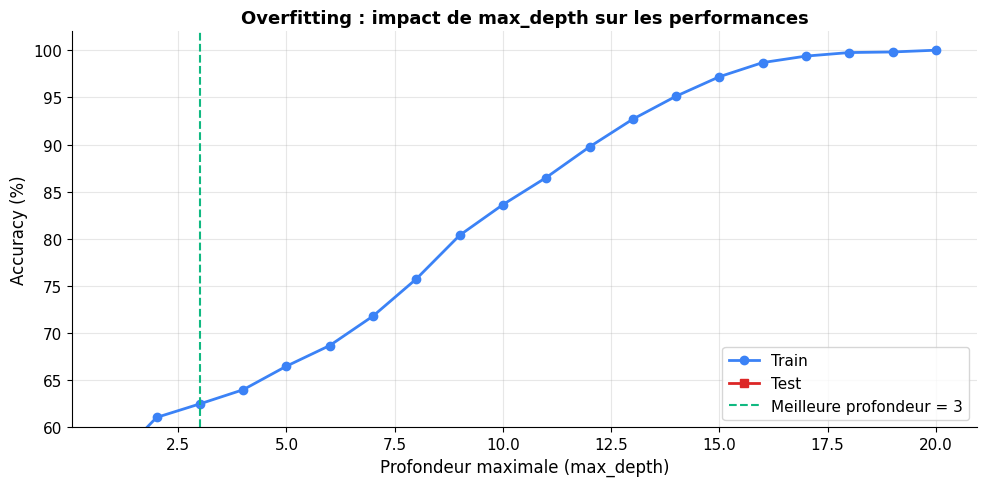

→ Meilleure profondeur sur le test : 3
→ Accuracy test correspondante     : 58.50%


In [18]:
# Évolution des performances selon max_depth
depths     = range(1, 21)
acc_trains = []
acc_tests  = []

for d in depths:
    clf_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf_d.fit(X_train, y_train)
    acc_trains.append(accuracy_score(y_train, clf_d.predict(X_train)))
    acc_tests.append(accuracy_score(y_test, clf_d.predict(X_test)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, [a*100 for a in acc_trains], 'o-',
        color='#3B82F6', label='Train', linewidth=2)
ax.plot(depths, [a*100 for a in acc_tests], 's-',
        color='#DC2626', label='Test', linewidth=2)

best_depth = depths[np.argmax(acc_tests)]
ax.axvline(best_depth, color='#10B981', linestyle='--', linewidth=1.5,
           label=f'Meilleure profondeur = {best_depth}')

ax.set_xlabel('Profondeur maximale (max_depth)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Overfitting : impact de max_depth sur les performances',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(60, 102)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'→ Meilleure profondeur sur le test : {best_depth}')
print(f'→ Accuracy test correspondante     : {max(acc_tests)*100:.2f}%')

### 4.3 Modèle optimisé

In [19]:
# ── Modèle avec hyperparamètres contrôlés ────────────────
clf_opt = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=10,
    min_samples_split=20,
    criterion='gini',
    random_state=42
)
clf_opt.fit(X_train, y_train)

y_pred_opt = clf_opt.predict(X_test)
y_proba_opt = clf_opt.predict_proba(X_test)[:, 1]

print('━' * 45)
print('  MODÈLE OPTIMISÉ')
print('━' * 45)
print(f'  Accuracy Train  : {accuracy_score(y_train, clf_opt.predict(X_train))*100:.2f}%')
print(f'  Accuracy Test   : {accuracy_score(y_test, y_pred_opt)*100:.2f}%')
print(f'  ROC-AUC         : {roc_auc_score(y_test, y_proba_opt):.4f}')
print(f'  Profondeur      : {clf_opt.get_depth()}')
print(f'  Nb de feuilles  : {clf_opt.get_n_leaves()}')
print('━' * 45)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODÈLE OPTIMISÉ
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy Train  : 62.50%
  Accuracy Test   : 58.50%
  ROC-AUC         : 0.5988
  Profondeur      : 3
  Nb de feuilles  : 8
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### 4.4 Rapport de classification & Matrice de confusion

RAPPORT DE CLASSIFICATION :
                   precision    recall  f1-score   support

Pas de défaut (0)       0.54      0.35      0.43       175
       Défaut (1)       0.60      0.76      0.67       225

         accuracy                           0.58       400
        macro avg       0.57      0.56      0.55       400
     weighted avg       0.58      0.58      0.57       400



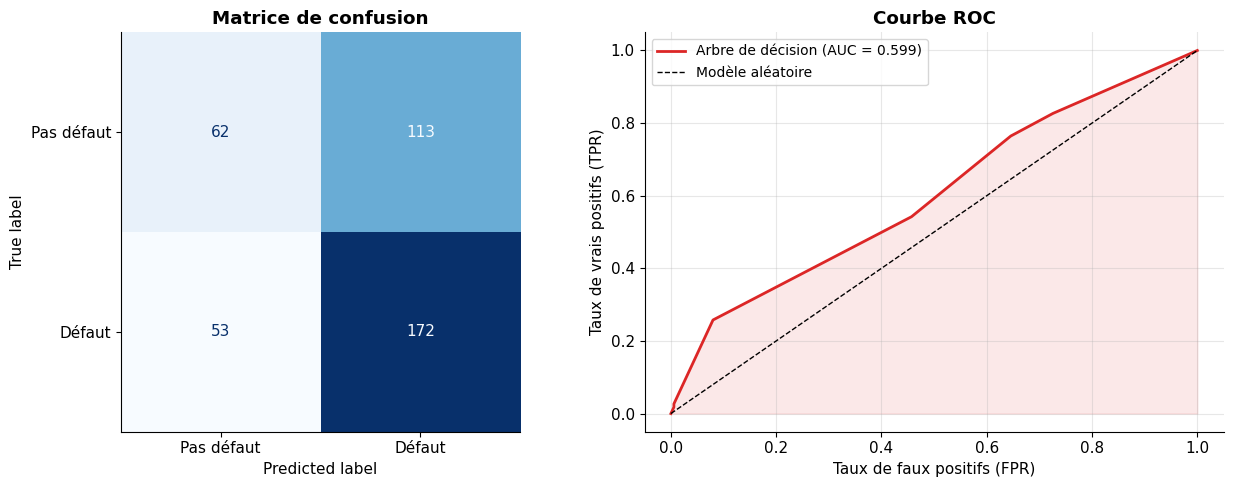

In [20]:
# ── Rapport de classification ─────────────────────────────
print('RAPPORT DE CLASSIFICATION :')
print(classification_report(y_test, y_pred_opt,
      target_names=['Pas de défaut (0)', 'Défaut (1)']))

# ── Matrice de confusion ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(cm, display_labels=['Pas défaut', 'Défaut'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matrice de confusion', fontweight='bold')

# ── Courbe ROC ────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba_opt)
auc = roc_auc_score(y_test, y_proba_opt)
axes[1].plot(fpr, tpr, color='#DC2626', linewidth=2,
             label=f'Arbre de décision (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1, label='Modèle aléatoire')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#DC2626')
axes[1].set_xlabel('Taux de faux positifs (FPR)')
axes[1].set_ylabel('Taux de vrais positifs (TPR)')
axes[1].set_title('Courbe ROC', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

> **🏦 Interprétation métier :**
> - **Précision** (Défaut) = Parmi les clients prédits en défaut, combien le sont vraiment ?
> - **Rappel** (Défaut) = Parmi les vrais défauts, combien le modèle détecte-t-il ?
> - En banque, on préfère souvent un **rappel élevé** (détecter un maximum de défauts)
>   quitte à avoir plus de faux positifs (refuser des bons clients).

### 4.5 Visualisation de l'arbre de décision

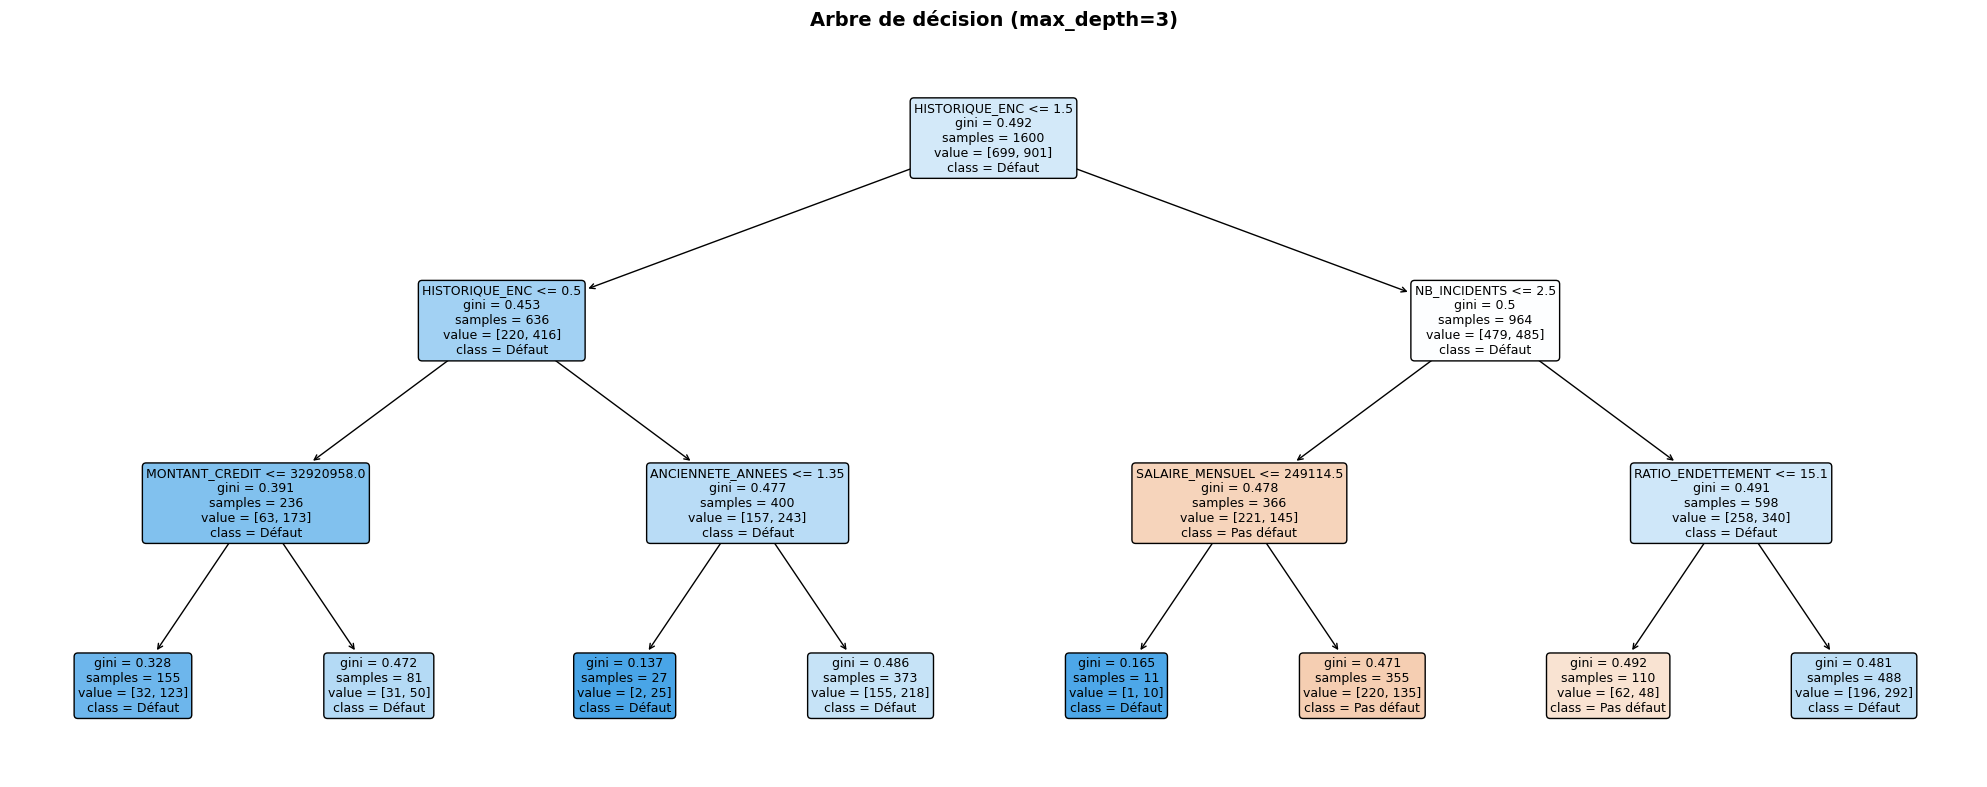


Règles de l'arbre (format texte) :
|--- HISTORIQUE_ENC <= 1.50
|   |--- HISTORIQUE_ENC <= 0.50
|   |   |--- MONTANT_CREDIT <= 32920958.00
|   |   |   |--- class: 1
|   |   |--- MONTANT_CREDIT >  32920958.00
|   |   |   |--- class: 1
|   |--- HISTORIQUE_ENC >  0.50
|   |   |--- ANCIENNETE_ANNEES <= 1.35
|   |   |   |--- class: 1
|   |   |--- ANCIENNETE_ANNEES >  1.35
|   |   |   |--- class: 1
|--- HISTORIQUE_ENC >  1.50
|   |--- NB_INCIDENTS <= 2.50
|   |   |--- SALAIRE_MENSUEL <= 249114.50
|   |   |   |--- class: 1
|   |   |--- SALAIRE_MENSUEL >  249114.50
|   |   |   |--- class: 0
|   |--- NB_INCIDENTS >  2.50
|   |   |--- RATIO_ENDETTEMENT <= 15.10
|   |   |   |--- class: 0
|   |   |--- RATIO_ENDETTEMENT >  15.10
|   |   |   |--- class: 1



In [21]:
# Visualisation (limitée à depth=3 pour la lisibilité)
clf_viz = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=42)
clf_viz.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    clf_viz,
    feature_names=FEATURES,
    class_names=['Pas défaut', 'Défaut'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=True,
    proportion=False,
)
ax.set_title('Arbre de décision (max_depth=3)',
             fontweight='bold', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Version texte (plus lisible pour l'analyse)
print('\nRègles de l\'arbre (format texte) :')
print(export_text(clf_viz, feature_names=FEATURES, max_depth=2))

### 4.6 Importance des variables

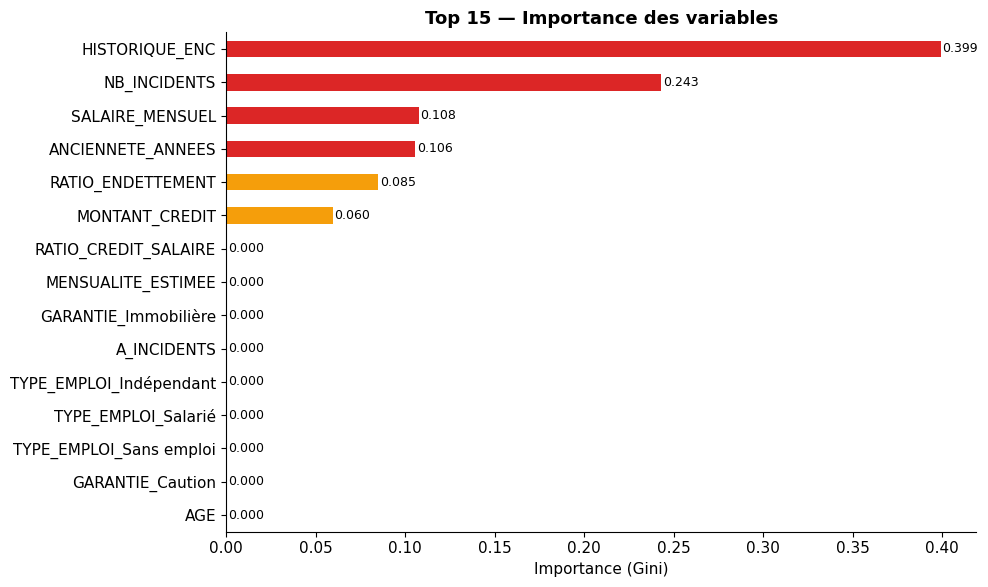


🔍 Les 5 variables les plus importantes :
  HISTORIQUE_ENC                      : 0.3991 (39.9%)
  NB_INCIDENTS                        : 0.2431 (24.3%)
  SALAIRE_MENSUEL                     : 0.1075 (10.8%)
  ANCIENNETE_ANNEES                   : 0.1058 (10.6%)
  RATIO_ENDETTEMENT                   : 0.0849 (8.5%)


In [22]:
importances = pd.Series(
    clf_opt.feature_importances_, index=FEATURES
).sort_values(ascending=True)

# Garder les 15 plus importantes
top15 = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#DC2626' if v > top15.quantile(0.75) else
          '#F59E0B' if v > top15.quantile(0.5) else '#3B82F6'
          for v in top15.values]
top15.plot(kind='barh', ax=ax, color=colors)

ax.set_xlabel('Importance (Gini)')
ax.set_title('Top 15 — Importance des variables', fontweight='bold', fontsize=13)

for i, (name, val) in enumerate(top15.items()):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\n🔍 Les 5 variables les plus importantes :')
for feat, imp in importances.nlargest(5).items():
    print(f'  {feat:35} : {imp:.4f} ({imp*100:.1f}%)')

---
## ⚙️ 5. Optimisation des hyperparamètres
---

### 5.1 GridSearchCV — Recherche exhaustive

In [23]:
# Grille de paramètres à tester
param_grid = {
    'max_depth':         [3, 4, 5, 6, 7, 8],
    'min_samples_split': [10, 20, 30, 50],
    'min_samples_leaf':  [5, 10, 15, 20],
    'criterion':         ['gini', 'entropy'],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,                    # validation croisée 5 folds
    scoring='roc_auc',       # métrique d'optimisation
    n_jobs=-1,               # parallélisation
    verbose=0
)
grid_search.fit(X_train, y_train)

print('✅ GridSearchCV terminé')
print(f'\n  Meilleurs paramètres  :')
for param, val in grid_search.best_params_.items():
    print(f'    {param:25} : {val}')
print(f'\n  Meilleur ROC-AUC (CV) : {grid_search.best_score_:.4f}')

✅ GridSearchCV terminé

  Meilleurs paramètres  :
    criterion                 : entropy
    max_depth                 : 3
    min_samples_leaf          : 10
    min_samples_split         : 10

  Meilleur ROC-AUC (CV) : 0.5960


In [24]:
# Évaluation du meilleur modèle sur le test
clf_best = grid_search.best_estimator_
y_pred_best  = clf_best.predict(X_test)
y_proba_best = clf_best.predict_proba(X_test)[:, 1]

print('━' * 50)
print('  COMPARAISON DES MODÈLES')
print('━' * 50)
print(f'  {"Modèle":<25} {"Accuracy":>10} {"ROC-AUC":>10}')
print('  ' + '-'*46)

modeles = {
    'Base (sans contraintes)': (clf_base, X_test, y_test),
    'Optimisé manuellement':   (clf_opt,  X_test, y_test),
    'GridSearchCV':            (clf_best, X_test, y_test),
}
for nom, (clf, Xt, yt) in modeles.items():
    acc  = accuracy_score(yt, clf.predict(Xt))
    auc  = roc_auc_score(yt, clf.predict_proba(Xt)[:, 1])
    print(f'  {nom:<25} {acc*100:>9.2f}% {auc:>10.4f}')
print('━' * 50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  COMPARAISON DES MODÈLES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Modèle                      Accuracy    ROC-AUC
  ----------------------------------------------
  Base (sans contraintes)       54.00%     0.5371
  Optimisé manuellement         58.50%     0.5988
  GridSearchCV                  58.50%     0.5964
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [29]:
import joblib

joblib.dump(clf_best, "modele_arbre_risk_cred.pkl")

['modele_arbre_risk_cred.pkl']

> **✏️ Exercice 4** — Évaluez l'impact du paramètre `class_weight='balanced'` sur le rappel (recall) de la classe Défaut. Quand est-il conseillé de l'utiliser ?

In [ ]:
# Exercice 4 — Impact de class_weight
clf_balanced = DecisionTreeClassifier(
    # Complétez les paramètres
    random_state=42
)
# Votre code ici


> **✏️ Exercice 5** — Utilisez le Cost-Complexity Pruning pour trouver le meilleur alpha. Tracez l'évolution de l'accuracy en fonction d'alpha.

In [ ]:
# Exercice 5 — Post-élagage (CCP)
# path = clf_opt.cost_complexity_pruning_path(X_train, y_train)
# Votre code ici


> **✏️ Exercice 6** — **Synthèse** : Rédigez un paragraphe d'interprétation métier de votre meilleur modèle. Quelles sont les 3 principales variables qui prédisent le défaut ? Que conseilleriez-vous à la direction Risque ?

In [ ]:
# Exercice 6 — Interprétation métier
# Remplacez ce commentaire par votre analyse

# Résumé du modèle
print('Mon meilleur modèle : ...')
print('Variables clés      : ...')
print('Recommandations     : ...')


---
## 🏁 Conclusion & Perspectives
---

## Ce que vous avez appris

| Étape | Compétence acquise |
|-------|-------------------|
| Chargement | Créer un dataset réaliste, identifier sa structure |
| EDA | Analyser distributions, corrélations, taux de défaut par segment |
| Prétraitement | Imputer les NaN, encoder, créer des features |
| Modélisation | Construire, évaluer et visualiser un arbre de décision |
| Optimisation | GridSearchCV, analyse de l'overfitting, élagage |
| Interprétation | Lire une matrice de confusion, courbe ROC, feature importance |

---

## Perspectives — Aller plus loin

1. **Random Forest** : agrégation de nombreux arbres → réduit l'instabilité
2. **Gradient Boosting** (XGBoost, LightGBM) : arbres appris séquentiellement → plus précis
3. **SHAP** : interprétabilité avancée des prédictions individuelles
4. **Validation temporelle** : en banque, le split doit être chronologique (pas aléatoire)
5. **Coût asymétrique** : pondérer les erreurs (un défaut non détecté coûte plus cher qu'un refus)

---

> *"Tous les modèles sont faux, mais certains sont utiles."* — George Box